# CUDA SGEMM — Colab runner

This notebook is a thin runner. Your code lives in the GitHub repo; this just
clones it, compiles the kernels on a GPU, benchmarks them, and regenerates the
chart. Nothing is edited here.

**Before running:** `Runtime -> Change runtime type -> T4 GPU`.

Workflow: edit `.cu` files locally -> `git push` -> re-run this notebook.

In [9]:
# 1. Confirm we have a GPU and check its compute capability (sets ARCH).
!nvidia-smi --query-gpu=name,compute_cap --format=csv

name, compute_cap
Tesla T4, 7.5


In [10]:
# 2. Clone your repo. EDIT this URL to your GitHub repo.
REPO = 'https://github.com/legokito/Practice.git'
!rm -rf Practice && git clone --depth 1 $REPO
%cd Practice/cuda-sgemm

Cloning into 'Practice'...
remote: Enumerating objects: 27, done.
remote: Counting objects: 100% (27/27), done.
remote: Compressing objects: 100% (22/22), done.
remote: Total 27 (delta 6), reused 17 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (27/27), 33.88 KiB | 754.00 KiB/s, done.
Resolving deltas: 100% (6/6), done.
/content/Practice/cuda-sgemm/Practice/cuda-sgemm/Practice/cuda-sgemm


In [11]:
# 3. Build. T4 == sm_75. (A100=sm_80, L4=sm_89 — match the card above.)
!make clean && make ARCH=sm_75

rm -f sgemm
nvcc -O3 -arch=sm_75 -std=c++14 -Isrc src/runner.cu src/kernels/01_naive.cu src/kernels/02_gmem_coalesce.cu src/kernels/03_shared_mem_block.cu src/kernels/04_1d_blocktiling.cu src/kernels/05_2d_blocktiling.cu src/kernels/06_vectorized.cu src/kernels/09_autotuning.cu src/kernels/10_warptiling.cu -o sgemm -lcublas


In [12]:
# 4. Benchmark every implemented kernel at 4096x4096 -> benchmark/results.csv
#    Stub kernels are skipped automatically.
!bash benchmark/run_benchmarks.sh 4096 20
print('\n--- results.csv ---')
!cat benchmark/results.csv

0,cuBLAS,4096,4211.2,0.00e+00,OK
1,01_naive,4096,61.9,0.00e+00,OK
2,02_gmem_coalesce,4096,473.9,0.00e+00,OK
kernel 3: skipped (not implemented)
kernel 4: skipped (not implemented)
kernel 5: skipped (not implemented)
kernel 6: skipped (not implemented)
kernel 9: skipped (not implemented)
kernel 10: skipped (not implemented)

wrote /content/Practice/cuda-sgemm/Practice/cuda-sgemm/Practice/cuda-sgemm/benchmark/results.csv

--- results.csv ---
kernel_id,name,size,gflops,max_rel_err,status
0,cuBLAS,4096,4211.2,0.00e+00,OK
1,01_naive,4096,61.9,0.00e+00,OK
2,02_gmem_coalesce,4096,473.9,0.00e+00,OK


wrote assets/benchmark.png


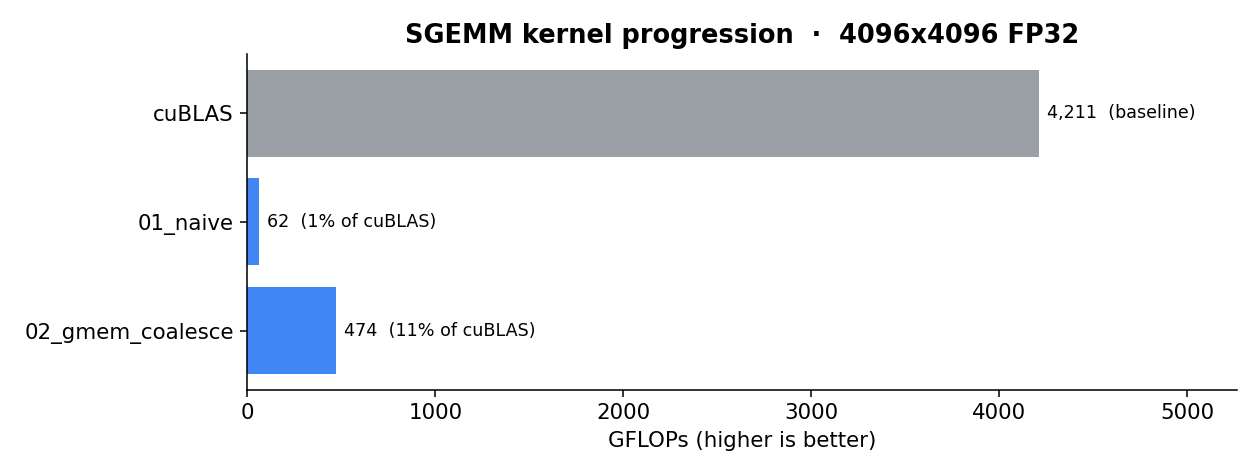

In [13]:
# 5. Render the chart from YOUR numbers and show it inline.
!python benchmark/plot.py benchmark/results.csv assets/benchmark.png
from IPython.display import Image
Image('assets/benchmark.png')

In [14]:
from google.colab import files
files.download('assets/benchmark.png')
files.download('benchmark/results.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 6. Commit your results back (optional)

Download `benchmark/results.csv` and `assets/benchmark.png` and commit them
from your laptop, **or** push straight from Colab with a GitHub token:

```python
# TOKEN = 'ghp_...'  # a fine-grained PAT with contents:write on this repo
# !git config user.email 'you@example.com' && git config user.name 'You'
# !git add benchmark/results.csv assets/benchmark.png
# !git commit -m 'bench: T4 results'
# !git push https://$TOKEN@github.com/YOUR_USERNAME/Practice.git HEAD:main
```